<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/CDMA_DSSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CDMA / DSSS
## Direct-Sequence Spread Spectrum with 3 users, 4-chip codes, 2 bits each

**Convention:** `0 → +1`, `1 → −1`  
**Chip codes (polar):**

| User | Binary code | Polar code |
|------|-------------|------------|
| A | 0011 | −1 −1 +1 +1 |
| B | 0101 | −1 +1 −1 +1 |
| C | 0110 | −1 +1 +1 −1 |

**Data bits to transmit:**

| User | Bit 1 | Bit 2 |
|------|-------|-------|
| A | 0 | 1 |
| B | 1 | 0 |
| C | 0 | 0 |

---
Run all cells top-to-bottom (`Runtime → Run all`).

## Setup
Install Matplotlib extras if needed and import all libraries.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from IPython.display import display

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
})
print('Libraries loaded.')

Libraries loaded.


## Helper: waveform builder
Converts a list of chip values into a staircase waveform for plotting.

In [ ]:
def make_waveform(chips):
    """Return (x, y) staircase arrays for a chip sequence."""
    x, y = [], []
    for i, v in enumerate(chips):
        x += [i, i + 1]
        y += [v, v]
    return np.array(x), np.array(y)


def annotate_chips(ax, chips, y_offset=0.15, color='#444'):
    """Print chip value above or below each chip slot."""
    for i, v in enumerate(chips):
        sign = '+' if v > 0 else ''
        ax.text(i + 0.5, v + y_offset * np.sign(v),
                f'{sign}{v}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')


def draw_period_dividers(ax, n_chips=4, n_periods=2, ymin=-1.6, ymax=1.6):
    """Draw vertical dashed lines between bit periods."""
    for p in range(1, n_periods):
        ax.axvline(p * n_chips, color='#AAAAAA', lw=1.2, ls='--')
    for p in range(n_periods):
        # ax.text(p * n_chips + n_chips / 2,
        #         ymax - 0.08 * (ymax - ymin),
        #         f'Period {p + 1}', ha='center', va='top',
        #         fontsize=9, color='#888', style='italic')

        ax.text(p*n_chips + n_chips/2,
        1.03,
        f'Period {p+1}',
        transform=ax.get_xaxis_transform(),
        ha='center',
        fontsize=9,
        color='#888',
        style='italic')


print('Helpers defined.')

Helpers defined.


---
## Step 1 — Bit mapping & spreading

Each bit is mapped to a polar value (`0→+1`, `1→−1`) and then **multiplied chip-by-chip** with the user's code:

$$\text{spread}[k] = \text{polar\_bit} \times \text{code}[k \bmod 4]$$

This produces 8 chips total per user (4 per bit period).

In [ ]:
# ── System parameters ────────────────────────────────────────────────────
CHIPS_PER_BIT = 4
N_BITS        = 2
N_USERS       = 3

# Chip codes (polar: 0→−1 in binary, but here already in polar)
codes = {
    'A': np.array([-1, -1, +1, +1]),
    'B': np.array([-1, +1, -1, +1]),
    'C': np.array([-1, +1, +1, -1]),
}

# Data bits (0 or 1)
bits = {
    'A': [0, 1],
    'B': [1, 0],
    'C': [1, 0],
}

# Polar mapping
def polar(b): return +1 if b == 0 else -1

# Build spread sequences (8 chips each)
spread = {}
for u in ['A', 'B', 'C']:
    seq = []
    for b in bits[u]:
        seq.extend(codes[u] * polar(b))
    spread[u] = np.array(seq)
    print(f'User {u} | bits={bits[u]} | spread={spread[u].tolist()}')

User A | bits=[0, 1] | spread=[-1, -1, 1, 1, 1, 1, -1, -1]
User B | bits=[1, 0] | spread=[1, -1, 1, -1, -1, 1, -1, 1]
User C | bits=[1, 0] | spread=[1, -1, -1, 1, -1, 1, 1, -1]


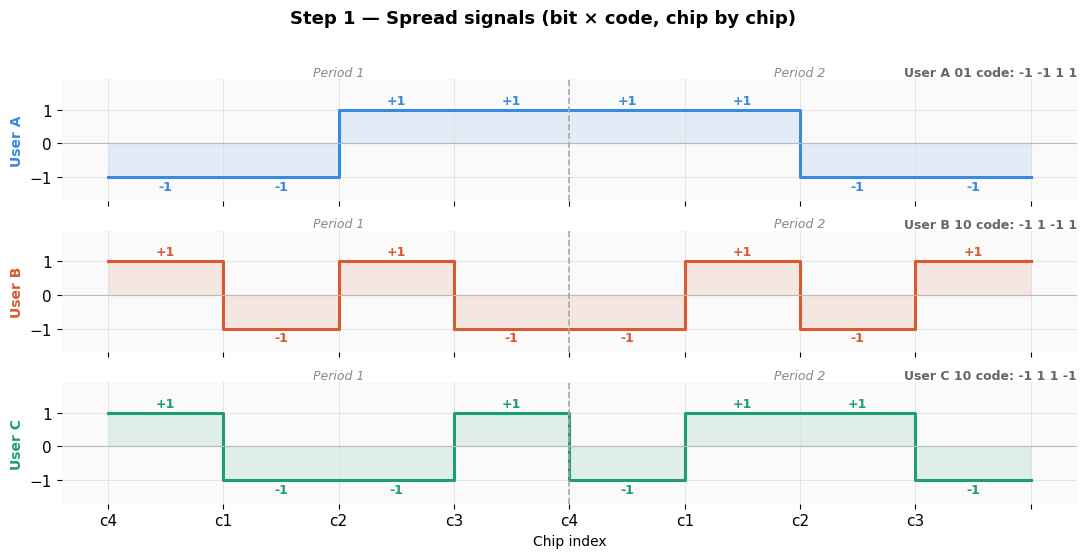

In [ ]:
# ── Plot Step 1 ──────────────────────────────────────────────────────────
COLORS = {'A': '#378ADD', 'B': '#D85A30', 'C': '#1D9E75'}

NAMES = {
    u: f"User {u} {''.join(map(str, bits[u]))} code: {' '.join(map(str, codes[u]))}"
    for u in bits
}

fig, axes = plt.subplots(3, 1, figsize=(11, 5.5), sharex=True)
fig.suptitle('Step 1 — Spread signals (bit × code, chip by chip)', fontsize=13, fontweight='bold', y=1.01)

for ax, u in zip(axes, ['A', 'B', 'C']):
    x, y = make_waveform(spread[u])
    ax.plot(x, y, color=COLORS[u], lw=2.2)
    ax.fill_between(x, 0, y, alpha=0.12, color=COLORS[u])
    ax.axhline(0, color='#BBBBBB', lw=0.8)
    ax.set_ylim(-1.7, 1.9)
    ax.set_yticks([-1, 0, 1])
    ax.set_ylabel(f'User {u}', fontsize=10, color=COLORS[u], fontweight='bold')
    ax.set_title(NAMES[u], fontsize=9, color='#666', loc='right', pad=2)
    # chip value labels
    for i, v in enumerate(spread[u]):
        s = '+' if v > 0 else ''
        ax.text(i + 0.5, v + 0.28 * np.sign(v), f'{s}{int(v)}',
                ha='center', va='center', fontsize=9,
                color=COLORS[u], fontweight='bold')
    draw_period_dividers(ax, ymin=-1.7, ymax=1.9)

axes[-1].set_xlabel('Chip index', fontsize=10)
axes[-1].set_xticks(range(9))
axes[-1].set_xticklabels([f'c{i%4 or 4}' if i < 8 else '' for i in range(9)])
plt.tight_layout()
plt.savefig('step1_spread.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2 — Channel summation  S = A + B + C

All users transmit simultaneously. The received channel signal is the **chip-wise sum** of all three spread sequences:

$$S[k] = \text{spread}_A[k] + \text{spread}_B[k] + \text{spread}_C[k]$$

Values can reach ±3 (all three users aligned) or land on ±1 (partial cancellation).

In [ ]:
# ── Compute channel signal ───────────────────────────────────────────────
S = spread['A'] + spread['B'] + spread['C']
print(f'S1 (period 1) = {S[:4].tolist()}')
print(f'S2 (period 2) = {S[4:].tolist()}')

S1 (period 1) = [1, -3, 1, 1]
S2 (period 2) = [-1, 3, -1, -1]


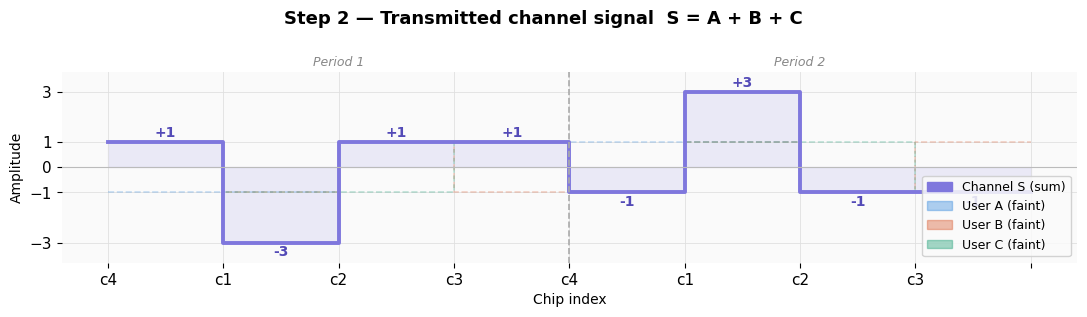

In [ ]:
# ── Plot Step 2 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.2))
fig.suptitle('Step 2 — Transmitted channel signal  S = A + B + C', fontsize=13, fontweight='bold')

# Individual spread signals (faint background)
for u in ['A', 'B', 'C']:
    xi, yi = make_waveform(spread[u])
    ax.plot(xi, yi, color=COLORS[u], lw=1.2, alpha=0.28, ls='--')

# Channel sum (bold)
xs, ys = make_waveform(S)
ax.plot(xs, ys, color='#7F77DD', lw=2.8)
ax.fill_between(xs, 0, ys, alpha=0.13, color='#7F77DD')
ax.axhline(0, color='#BBBBBB', lw=0.8)
ax.set_ylim(-3.8, 3.8)
ax.set_yticks([-3, -1, 0, 1, 3])
ax.set_ylabel('Amplitude', fontsize=10)
ax.set_xlabel('Chip index', fontsize=10)
ax.set_xticks(range(9))
ax.set_xticklabels([f'c{i%4 or 4}' if i < 8 else '' for i in range(9)])

# Annotate S values
for i, v in enumerate(S):
    s = '+' if v > 0 else ''
    ax.text(i + 0.5, v + 0.38 * np.sign(v), f'{s}{int(v)}',
            ha='center', va='center', fontsize=10,
            color='#534AB7', fontweight='bold')

draw_period_dividers(ax, ymin=-3.8, ymax=3.8)

# Legend
patches = [
    mpatches.Patch(color='#7F77DD', label='Channel S (sum)'),
    mpatches.Patch(color=COLORS['A'], alpha=0.4, label='User A (faint)'),
    mpatches.Patch(color=COLORS['B'], alpha=0.4, label='User B (faint)'),
    mpatches.Patch(color=COLORS['C'], alpha=0.4, label='User C (faint)'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right', framealpha=0.85)
plt.tight_layout()
plt.savefig('step2_channel.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3 — Correlation (dot product)

Each receiver multiplies **S chip-by-chip** with its own code, then sums over one period:

$$\text{corr}_u[p] = \sum_{k=0}^{3} S[4p+k] \times \text{code}_u[k]$$

Because the three codes are **mutually orthogonal**, all cross-terms cancel to zero and only the target user's signal survives.

In [ ]:
# ── Compute correlation products ─────────────────────────────────────────
full_codes = {'A': np.tile(codes['A'], 2),
              'B': np.tile(codes['B'], 2),
              'C': np.tile(codes['C'], 2)}

corr_products = {u: S * full_codes[u] for u in ['A', 'B', 'C']}

for u in ['A', 'B', 'C']:
    p = corr_products[u]
    s1 = int(p[:4].sum())
    s2 = int(p[4:].sum())
    print(f'User {u}: products={p.tolist()}  |  sum P1={s1}  sum P2={s2}')

User A: products=[-1, 3, 1, 1, 1, -3, -1, -1]  |  sum P1=4  sum P2=-4
User B: products=[-1, -3, -1, 1, 1, 3, 1, -1]  |  sum P1=-4  sum P2=4
User C: products=[-1, -3, 1, -1, 1, 3, -1, 1]  |  sum P1=-4  sum P2=4


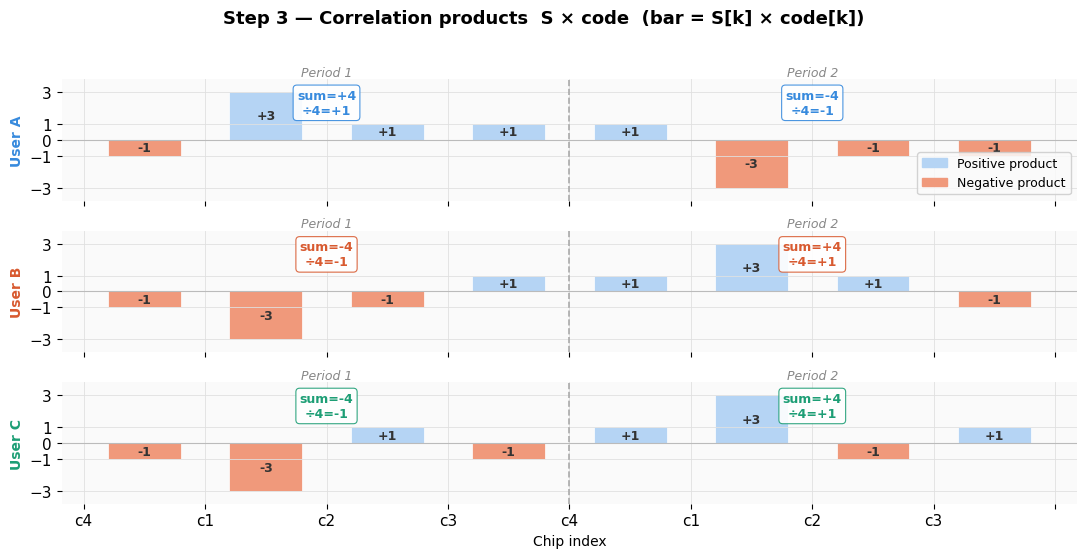

In [ ]:
# ── Plot Step 3 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 5.5), sharex=True)
fig.suptitle('Step 3 — Correlation products  S × code  (bar = S[k] × code[k])', fontsize=13, fontweight='bold', y=1.01)

chip_idx = np.arange(8)
bar_w = 0.6
clr_pos, clr_neg = '#B5D4F4', '#F0997B'

for ax, u in zip(axes, ['A', 'B', 'C']):
    prods = corr_products[u]
    colors = [clr_pos if v >= 0 else clr_neg for v in prods]
    bars = ax.bar(chip_idx + 0.5, prods, width=bar_w,
                  color=colors, edgecolor='white', linewidth=0.5)

    # value labels inside bars
    for i, v in enumerate(prods):
        s = '+' if v > 0 else ''
        ax.text(i + 0.5, v * 0.5, f'{s}{int(v)}',
                ha='center', va='center', fontsize=9,
                color='#333', fontweight='bold')

    # period sum annotations
    for p in range(2):
        total = int(prods[p*4:(p+1)*4].sum())
        s = '+' if total > 0 else ''
        ax.text(p*4 + 2, 3.2, f'sum={s}{total}\n÷4={s}{total//4}',
                ha='center', va='top', fontsize=9,
                color=COLORS[u], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS[u], lw=0.8, alpha=0.9))

    ax.axhline(0, color='#BBBBBB', lw=0.8)
    ax.set_ylim(-3.8, 3.8)
    ax.set_yticks([-3, -1, 0, 1, 3])
    ax.set_ylabel(f'User {u}', fontsize=10, color=COLORS[u], fontweight='bold')
    draw_period_dividers(ax, ymin=-3.8, ymax=3.8)

axes[-1].set_xlabel('Chip index', fontsize=10)
axes[-1].set_xticks(range(9))
axes[-1].set_xticklabels([f'c{i%4 or 4}' if i < 8 else '' for i in range(9)])

# Manual legend
patches = [mpatches.Patch(color=clr_pos, label='Positive product'),
           mpatches.Patch(color=clr_neg, label='Negative product')]
axes[0].legend(handles=patches, fontsize=9, loc='lower right', framealpha=0.85)

plt.tight_layout()
plt.savefig('step3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4 — Decision & decoded bits

Divide each period's correlation sum by N=4 (normalise), then decide:

$$\hat{b} = \begin{cases} 0 & \text{if } \text{corr} > 0 \\ 1 & \text{if } \text{corr} < 0 \end{cases}$$

Because the codes are orthogonal, the normalised value is exactly **+1** or **−1** — no noise, no ambiguity.

In [ ]:
# ── Compute decoded bits ─────────────────────────────────────────────────
decoded = {}
corr_norm = {}
for u in ['A', 'B', 'C']:
    p = corr_products[u]
    norms = [p[:4].sum() / CHIPS_PER_BIT, p[4:].sum() / CHIPS_PER_BIT]
    corr_norm[u] = norms
    decoded[u] = [0 if n > 0 else 1 for n in norms]
    match = decoded[u] == bits[u]
    print(f'User {u}: norm=[{norms[0]:+.0f}, {norms[1]:+.0f}] '
          f'-> decoded={decoded[u]}  sent={bits[u]}  match={decoded[u]==bits[u]}')

User A: norm=[+1, -1] -> decoded=[0, 1]  sent=[0, 1]  match=True
User B: norm=[-1, +1] -> decoded=[1, 0]  sent=[1, 0]  match=True
User C: norm=[-1, +1] -> decoded=[1, 0]  sent=[1, 0]  match=True


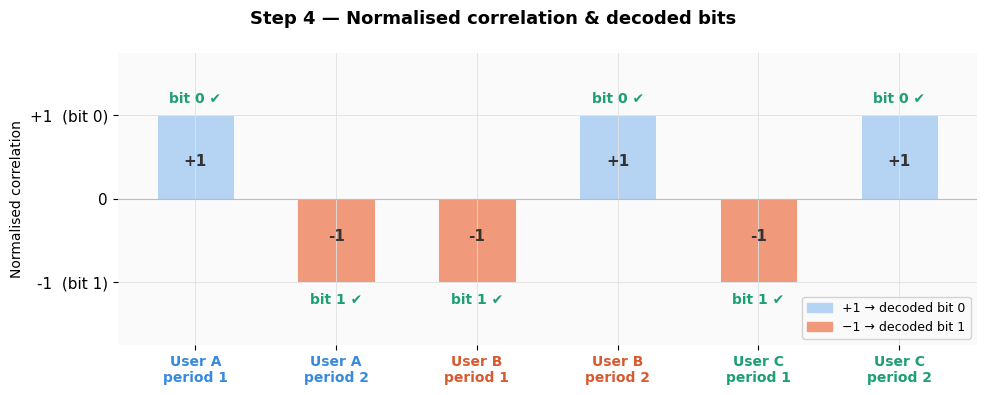

In [ ]:
# ── Plot Step 4 ──────────────────────────────────────────────────────────
users  = ['A', 'B', 'C']
n_bars = len(users) * N_BITS         # 6 bars
x      = np.arange(n_bars)
vals   = [corr_norm[u][p] for u in users for p in range(N_BITS)]
xlbls  = [f'User {u}\nperiod {p+1}' for u in users for p in range(N_BITS)]
bcolors = [('#B5D4F4' if v > 0 else '#F0997B') for v in vals]
user_c  = [COLORS[u] for u in users for _ in range(N_BITS)]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Step 4 — Normalised correlation & decoded bits', fontsize=13, fontweight='bold')

bars = ax.bar(x, vals, width=0.55, color=bcolors, edgecolor='white', linewidth=0.6)

for xi, v, u, p in zip(x, vals, [u for u in users for _ in range(N_BITS)],
                                  [p for _ in users for p in range(N_BITS)]):
    bit_out = 0 if v > 0 else 1
    sent    = bits[u][p]
    ok      = bit_out == sent
    s = '+' if v > 0 else ''
    # normalised value inside bar
    ax.text(xi, v * 0.45, f'{s}{v:.0f}',
            ha='center', va='center', fontsize=11, fontweight='bold', color='#333')
    # decoded bit + check above bar
    ax.text(xi, v + 0.12 * np.sign(v),
            f'bit {bit_out} {"\u2714" if ok else "\u2718"}',
            ha='center', va='bottom' if v > 0 else 'top',
            fontsize=10, color='#1D9E75' if ok else '#D85A30', fontweight='bold')

ax.axhline(0, color='#BBBBBB', lw=0.8)
ax.set_ylim(-1.75, 1.75)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['-1  (bit 1)', '0', '+1  (bit 0)'])
ax.set_ylabel('Normalised correlation', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(xlbls, fontsize=10)

# Colour the x-tick labels per user
for tick, c in zip(ax.get_xticklabels(), user_c):
    tick.set_color(c)
    tick.set_fontweight('bold')

patches = [mpatches.Patch(color='#B5D4F4', label='+1 → decoded bit 0'),
           mpatches.Patch(color='#F0997B', label='−1 → decoded bit 1')]
ax.legend(handles=patches, fontsize=9, loc='lower right', framealpha=0.85)

plt.tight_layout()
plt.savefig('step4_decision.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Bonus — Orthogonality verification

Two codes are **orthogonal** if their dot product equals zero.
That is exactly why other users' signals cancel during correlation.

In [ ]:
print('Pairwise dot products of chip codes:')
pairs = [('A','B'), ('A','C'), ('B','C')]
for u1, u2 in pairs:
    dp = int(np.dot(codes[u1], codes[u2]))
    print(f'  {u1}·{u2} = {codes[u1].tolist()} · {codes[u2].tolist()} = {dp}',
          '  <- orthogonal ✓' if dp == 0 else '  <- NOT orthogonal ✗')

Pairwise dot products of chip codes:
  A·B = [-1, -1, 1, 1] · [-1, 1, -1, 1] = 0   <- orthogonal ✓
  A·C = [-1, -1, 1, 1] · [-1, 1, 1, -1] = 0   <- orthogonal ✓
  B·C = [-1, 1, -1, 1] · [-1, 1, 1, -1] = 0   <- orthogonal ✓


---
## Summary

| User | Sent | Decoded | Match |
|------|------|---------|-------|
| A | 0, 1 | 0, 1 | ✓ |
| B | 1, 0 | 1, 0 | ✓ |
| C | 0, 0 | 0, 0 | ✓ |

All bits recovered perfectly because:
1. **Spreading** distributes each bit across 4 chips.
2. **Summation** mixes all users on one shared channel.
3. **Correlation** isolates each user via orthogonal codes.
4. **Decision** maps the ±1 result back to the original bit.